In [2]:
# STEP 1 — Import Libraries

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [14]:
# STEP 2 — Dataset Paths

cat_path = r"C:\Users\vijay\Downloads\kagglecatsanddogs_5340\PetImages\Cat"
dog_path = r"C:\Users\vijay\Downloads\kagglecatsanddogs_5340\PetImages\Dog"

In [15]:
#STEP 3 — Load Images

data = []
labels = []

# Limit images for faster training
limit = 500

In [16]:
# Load Cat Images

count = 0
for image_name in os.listdir(cat_path):
    if count >= limit:
        break
    image_path = os.path.join(cat_path, image_name)
    # Read image
    image = cv2.imread(image_path)
    # Skip corrupted images
    if image is None:
        continue
    try:
        # Resize image
        image = cv2.resize(image, (64, 64))
        # Flatten image
        image = image.flatten()
        # Store image data
        data.append(image)
        # Label = 0 for Cat
        labels.append(0)
        count += 1
    except:
        continue

In [17]:
# Load Dog Images

count = 0
for image_name in os.listdir(dog_path):
    if count >= limit:
        break
    image_path = os.path.join(dog_path, image_name)
    # Read image
    image = cv2.imread(image_path)
    # Skip corrupted images
    if image is None:
        continue
    try:
        # Resize image
        image = cv2.resize(image, (64, 64))
        # Flatten image
        image = image.flatten()
        # Store image data
        data.append(image)
        # Label = 1 for Dog
        labels.append(1)
        count += 1
    except:
        continue

In [18]:
# STEP 4 — Convert to NumPy Arrays

X = np.array(data)
y = np.array(labels)

print("\nDataset Loaded Successfully")
print("Total Images:", len(X))


Dataset Loaded Successfully
Total Images: 1000


In [19]:
# STEP 5 — Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# STEP 6 — Train SVM Model

print("\nTraining SVM Model...")
model = SVC(kernel='linear')
model.fit(X_train, y_train)


Training SVM Model...


SVC(kernel='linear')

In [21]:
# STEP 7 — Predictions

predictions = model.predict(X_test)

In [22]:
# STEP 8 — Evaluation

accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:")
print(f"{accuracy * 100:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))



Model Accuracy:
49.00%

Classification Report:

              precision    recall  f1-score   support

           0       0.47      0.55      0.51        96
           1       0.51      0.43      0.47       104

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.49      0.49      0.49       200




Enter image path to test:  10.jpg


C:\Users\vijay\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


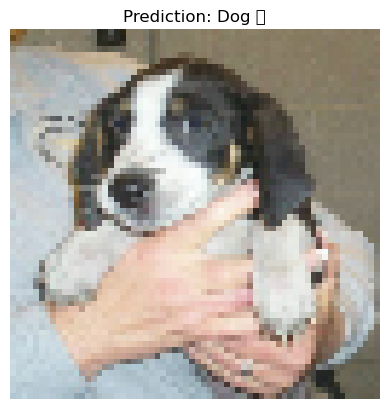

In [29]:
# STEP 9 — Test Custom Image

test_image_path = input("\nEnter image path to test: ")
test_image = cv2.imread(test_image_path)
if test_image is not None:
    # Resize image
    test_image = cv2.resize(test_image, (64, 64))
    # Store display image
    display_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
    # Flatten image
    test_image = test_image.flatten()
    # Convert to array
    test_image = np.array([test_image])
    # Prediction
    prediction = model.predict(test_image)
    # Show image
    plt.imshow(display_image)
    plt.axis("off")

    # Prediction result
    if prediction[0] == 0:
        plt.title("Prediction: Cat 🐱")
    else:
        plt.title("Prediction: Dog 🐶")
    plt.show()
else:
    print("Invalid Image Path")